In [2]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np

file_path = "output_segment_0.wav"

def load_audio_and_resample(file_path,sr):
    audio, sr = librosa.load(file_path, sr=sr)
    return audio, sr

audio_data, sample_rate = load_audio_and_resample(file_path, 16000)

In [3]:
# DC Offset Remove
def remove_dc_offset(data):
    mean_value = np.mean(data)
    return data - mean_value

In [4]:
def rms_normalize_audio(data, target_rms=0.1):
    rms = np.sqrt(np.mean(data**2))
    scaling_factor = target_rms / (rms + 1e-6) # 1e-6을 추가하는 이유는, 0으로 나누는것을 방지하기 위함
    return data * scaling_factor


normalized_audio = rms_normalize_audio(remove_dc_offset(audio_data))

- 원래는 mfcc 특징을 추출후, 전처리(노이즈 제거)를 하려고 하였으나, 배경소음이 정적노이즈 임을 고려하면 스펙트럼 게이팅을 하는것이 유용하다고 판단
    - Spectral Gating은 배경 소음(정적 노이즈)의 파워 스펙트럼을 추청하고, 신호의 각 주파수 대역이 그 추정값보다 작으면, 해당 대역의 값을 감소시키거가 0으로 만드는 방식. 
- 스펙트럼 게이팅은 mfcc를 추출하기 전에, 원본 오디오에 적용하는것이 일반적이므로, 먼저 진행 후 특징 추출할 예정

In [5]:
%pip install noisereduce

Note: you may need to restart the kernel to use updated packages.


In [6]:
import noisereduce as nr

def reduce_noise(data, sr):
    noise_sample = data[:sr]  # 처음 1초를 배경 소음으로 사용
    return nr.reduce_noise(y=audio_data, sr=sample_rate, y_noise=noise_sample)


denoised_audio = reduce_noise(normalized_audio, sample_rate)

In [7]:
denoised_audio

array([ 1.4478517e-04,  7.7104429e-05,  4.0934588e-05, ...,
       -3.0344562e-04, -4.4565363e-04, -5.9947382e-05], dtype=float32)

In [13]:
# Mel-spectrogram 생성
n_fft = 2048  # Fourier Transform window size
hop_length = 256  # window 간 이동 간격
n_mels = 128  # mel-spectrogram의 주파수 대역 수

mel_spec = librosa.feature.melspectrogram(
    y=denoised_audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

# dB 스케일로 변환 (시각적으로 더 직관적임)
db_scaled_mel = librosa.power_to_db(mel_spec, ref=np.max)

In [9]:
from pathlib import Path
file_name = Path(file_path).stem
file_name

'output_segment_0'

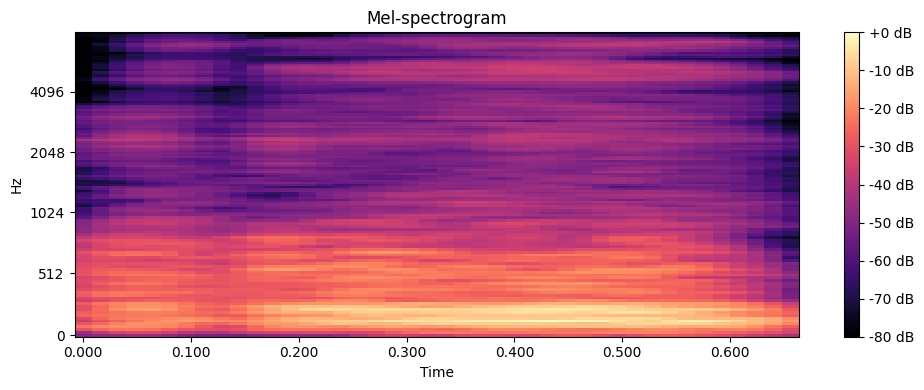

In [ ]:
# Mel-spectrogram 시각화 및 이미지 저장
plt.figure(figsize=(10, 4))
librosa.display.specshow(db_scaled_mel, sr=sample_rate, hop_length=hop_length,
                         x_axis='time', y_axis='mel')  # cmap='viridis'
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram")
plt.tight_layout()
plt.savefig('{}.png'.format(file_name))
plt.show()

## 데이터 노이즈 제거 전처리 
1) 병원에서 받아온 데이터 등은 segment처리 등을 해야하기 때문에 1초보다 커서, spectral gating을 진행할 수 있음.
2) 그러나, 오픈소스 데이터는 이미 1초 길이로 잘라져 있기 때문에, reduce_noise 라이브러리를 이용한 spectral gating 방식의 노이즈 제거를 할 수 없음. <br>
    -> 따라서, scipy라이브러리에서 median filter 방식을 사용할 수 있을거 같음. 

In [15]:
# Mel-spectrogram 생성
n_fft = 2048  # Fourier Transform window size
hop_length = 256  # window 간 이동 간격
n_mels = 128  # mel-spectrogram의 주파수 대역 수

mel_spec = librosa.feature.melspectrogram(
    y=normalized_audio, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)

# dB 스케일로 변환 (시각적으로 더 직관적임)
db_scaled_mel = librosa.power_to_db(mel_spec, ref=np.max)

In [16]:
from scipy.ndimage import median_filter

def median_filter_on_spectrogram(mel_spec_db, size=(1, 3)):
    # Apply median filter directly on the spectrogram
    filtered_spec = median_filter(mel_spec_db, size=size)
    return filtered_spec

In [17]:
# Apply median filter for noise reduction on spectrogram
noise_reduced_spec = median_filter_on_spectrogram(db_scaled_mel)

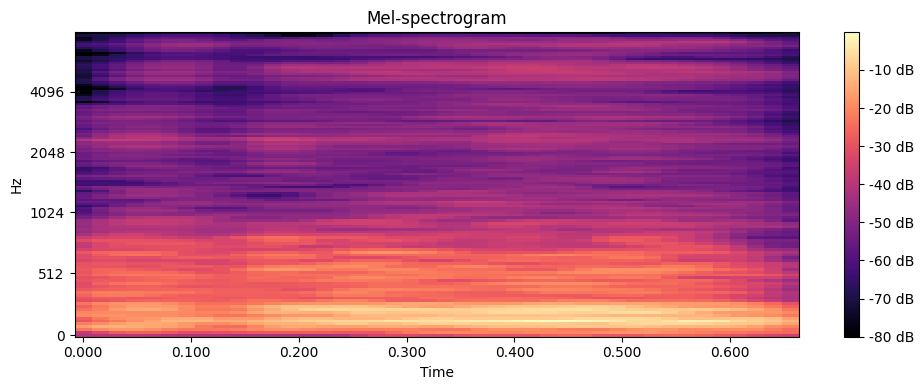

In [18]:
# Mel-spectrogram 시각화 및 이미지 저장
plt.figure(figsize=(10, 4))
librosa.display.specshow(noise_reduced_spec, sr=sample_rate, hop_length=hop_length,
                         x_axis='time', y_axis='mel')  # cmap='viridis'
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-spectrogram")
plt.tight_layout()
plt.show()

## MFCC 로 데이터 준비하기

In [23]:
def extract_mfcc(data, sr, n_mfcc=20, n_fft=2048, hop_length=256):
    '''
    Extracts MFCC (Mel Frequency Cepstral Coefficients) from audio data.

    Parameters:
    - data (numpy.ndarray): The input audio signal from which features are to be extracted.
    - sr (int): The sample rate of the audio signal, in Hertz (Hz).
    - n_mfcc (int): Number of MFCC features to extract. Default is 13, which is a commonly used number of MFCCs for speech/audio analysis.
    - n_fft (int): Length of the FFT window, which is used to determine the frequency resolution. A larger n_fft results in a higher frequency resolution, while a smaller value results in a higher time resolution. The default value is 2048.
        For snoring detection, experimenting with different n_fft values (e.g., 1024, 4096) can help determine which resolution best captures the important characteristics of snoring sounds.
    - hop_length (int): The number of samples between successive frames. This parameter controls how much overlap there is between adjacent windows. Default is 512, which means the windows overlap to provide a smoother analysis.
    Returns:
    - mfccs (numpy.ndarray): A 2D array containing the MFCC features, where each row corresponds to a specific MFCC coefficient and each column corresponds to a time frame.
    '''
    mfccs = librosa.feature.mfcc(
        y=data, # input audio
        sr=sr, # sample rate
        n_mfcc=n_mfcc, # number of mfcc feature 
        n_fft=n_fft, # FFT window size
        hop_length=hop_length) # 
    return mfccs

mfcc_features = extract_mfcc(denoised_audio, sample_rate)

In [24]:
mfcc_features

array([[-5.86620056e+02, -5.37849487e+02, -4.94249939e+02,
        -4.64384125e+02, -4.49189789e+02, -4.48714630e+02,
        -4.63046295e+02, -4.87606781e+02, -5.11031799e+02,
        -5.06977112e+02, -4.79823486e+02, -4.56663910e+02,
        -4.44448792e+02, -4.41700134e+02, -4.41750275e+02,
        -4.33377899e+02, -4.22047546e+02, -4.15348633e+02,
        -4.12860229e+02, -4.10933563e+02, -4.06672882e+02,
        -4.02107300e+02, -3.97948669e+02, -3.90890900e+02,
        -3.83223480e+02, -3.79038269e+02, -3.78833069e+02,
        -3.79874908e+02, -3.80497925e+02, -3.81501587e+02,
        -3.82125854e+02, -3.82955719e+02, -3.86558838e+02,
        -3.94191650e+02, -4.05500275e+02, -4.17883911e+02,
        -4.31013428e+02, -4.50493164e+02, -4.77052704e+02,
        -5.12992249e+02, -5.61896179e+02, -6.25485901e+02],
       [ 1.76333160e+02,  1.71756516e+02,  1.56044479e+02,
         1.39417191e+02,  1.28044037e+02,  1.21530624e+02,
         1.18538261e+02,  1.21628372e+02,  1.33076508e+

### 시각화

In [25]:
def visualize_mfcc(mfccs, sr, hop_length):
    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        mfccs, sr=sr, hop_length=hop_length, x_axis='time')
    plt.colorbar()
    plt.title('MFCC')
    plt.tight_layout
    plt.show()

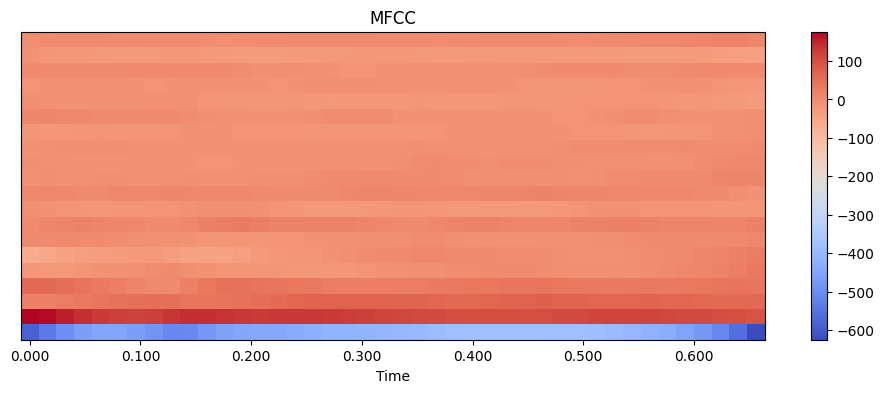

In [26]:
visualize_mfcc(mfcc_features, sample_rate, hop_length=256)